# 11 CatBoost ausprobieren

## Import

In [36]:
import time

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.metrics import roc_auc_score
from sklearn.base import clone

from catboost import CatBoostClassifier

import matplotlib as mpl
import matplotlib.pyplot as plt

In [37]:
mpl.style.use("seaborn-v0_8-colorblind")
RANDOM_STATE = 42

## Dataframe

In [38]:
df_raw = fetch_openml(data_id=42742, as_frame=True).frame

In [39]:
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")]
bin_cols = [col for col in feat_cols if col.endswith("_bin")]
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    df_raw[col] = df_raw[col].astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

idx_train = np.load("../../../data/processed/train_idx.npy")
idx_val = np.load("../../../data/processed/val_idx.npy")
idx_test = np.load("../../../data/processed/test_idx.npy")

df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

x_train, y_train = df_train[feat_cols], df_train["target"]
x_val, y_val = df_val[feat_cols], df_val["target"]
x_test, y_test = df_test[feat_cols], df_test["target"]
x_full, y_full = df_raw[feat_cols], df_raw["target"]

pd.Series(
    {
        "train": [len(df_train), len(x_train), len(y_train)],
        "val": [len(df_val), len(x_val), len(y_val)],
        "test": [len(df_test), len(x_test), len(y_test)],
        "full": [len(df_raw), len(x_full), len(y_full)]
    }
)

train    [476168, 476168, 476168]
val         [59522, 59522, 59522]
test        [59522, 59522, 59522]
full     [595212, 595212, 595212]
dtype: object

## Hilfsvariablen

In [40]:
calc_cols = [c for c in feat_cols if c.startswith("ps_calc_")]

mv_cols = ["ps_car_03_cat", "ps_car_05_cat", "ps_reg_03", "ps_car_14"]

num_cols_no_calc = [c for c in num_cols if c not in calc_cols]
bin_cols_no_calc = [c for c in bin_cols if c not in calc_cols]
feat_cols_no_calc = [c for c in feat_cols if c not in calc_cols]

high_kard_cols = ["ps_car_11_cat"]
low_kard_cols = [c for c in cat_cols if c not in high_kard_cols]

In [41]:
train_times = {}
results = []

In [42]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, train_time, best_iter=None):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "gini": 2 * auc_val - 1,
        "delta_auc": auc_train - auc_val,
        "best_iter": best_iter,
        "trainingszeit": train_time
    }

In [43]:
def mv_for_cb(df, fill_var="missing"):
    """df copy mit ersetzten nans"""
    outs = df.copy()
    for col in outs.columns:
        if outs[col].dtype.name == "category":
            if fill_var not in outs[col].cat.categories:
                outs[col] = outs[col].cat.add_categories([fill_var])
            outs[col] = outs[col].fillna(fill_var)
    return outs

In [44]:
x_train_cb = mv_for_cb(x_train)
x_val_cb = mv_for_cb(x_val)
x_test_cb = mv_for_cb(x_test)
x_full_cb = mv_for_cb(x_full)

pd.Series(
    {
        "train": len(x_train_cb),
        "val": len(x_val_cb),
        "test": len(x_val_cb),
        "full": len(x_full_cb)
    }
)

train    476168
val       59522
test      59522
full     595212
dtype: int64

## L_cb_01

In [45]:
L_cb_01 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    eval_metric="AUC",
    cat_features=cat_cols,
    verbose=250
)

In [46]:
name = "L_cb_01"

start = time.time()
L_cb_01.fit(
    x_train, y_train,
    eval_set=(x_val, y_val)
)
train_times[name] = time.time() - start

CatBoostError: Invalid type for cat_feature[object_idx=189,feature_idx=1]=NaN : cat_features must be integer or string, real number values and NaN values should be converted to string.

In [47]:
results.append(
    eval_modell(name, L_cb_01, x_train, y_train, x_val, y_val, train_times[name], best_iter=L_cb_01.get_best_iteration())
)
pd.DataFrame(results)

KeyError: 'L_cb_01'

## L_cb_02

In [48]:
prep_mv_for_cb = FunctionTransformer(mv_for_cb)

In [49]:
L_cb_02 = make_pipeline(
    make_column_transformer(
        (prep_mv_for_cb, low_kard_cols + high_kard_cols),
        ("passthrough", num_cols),
        ("passthrough", bin_cols)
    ).set_output(transform="pandas"),
    CatBoostClassifier(
        random_seed=RANDOM_STATE,
        eval_metric="AUC",
        cat_features=cat_cols,
        verbose=250
    )
)

In [50]:
name = "L_cb_02"

start = time.time()
L_cb_02.fit(
    x_train, y_train,
    eval_set=(x_val, y_val)
)
train_times[name] = time.time() - start

ValueError: Pipeline.fit does not accept the eval_set parameter. You can pass parameters to specific steps of your pipeline using the stepname__parameter format, e.g. `Pipeline.fit(X, y, logisticregression__sample_weight=sample_weight)`.

In [51]:
results.append(
    eval_modell(name, L_cb_02, x_train, y_train, x_val, y_val, train_times[name], best_iter=L_cb_02.get_best_iteration())
)
pd.DataFrame(results)

KeyError: 'L_cb_02'

## L_cb_03

In [52]:
L_cb_03 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    eval_metric="AUC",
    cat_features=cat_cols,
    verbose=250
)

In [53]:
name = "L_cb_03"

start = time.time()
L_cb_03.fit(
    x_train_cb, y_train,
    eval_set=(x_val_cb, y_val)
)
train_times[name] = time.time() - start

Learning rate set to 0.145317
0:	test: 0.5431933	best: 0.5431933 (0)	total: 318ms	remaining: 5m 17s
250:	test: 0.6287398	best: 0.6293726 (191)	total: 1m 19s	remaining: 3m 58s
500:	test: 0.6285437	best: 0.6293726 (191)	total: 2m 41s	remaining: 2m 40s
750:	test: 0.6293256	best: 0.6294542 (622)	total: 4m 1s	remaining: 1m 20s
999:	test: 0.6279261	best: 0.6294542 (622)	total: 5m 22s	remaining: 0us

bestTest = 0.629454207
bestIteration = 622

Shrink model to first 623 iterations.


In [54]:
results.append(
    eval_modell(name, L_cb_03, x_train_cb, y_train, x_val_cb, y_val, train_times[name], best_iter=L_cb_03.get_best_iteration())
)
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_03,0.707501,0.629454,0.258908,0.078047,622,323.952903


## L_cb_04

In [55]:
x_train_obj = x_train_cb.copy()
x_train_obj[cat_cols] = x_train_obj[cat_cols].astype("object")

x_val_obj = x_val_cb.copy()
x_val_obj[cat_cols] = x_val_obj[cat_cols].astype("object")

In [56]:
L_cb_04 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    eval_metric="AUC",
    cat_features=cat_cols,
    verbose=250
)

In [57]:
name = "L_cb_04"

start = time.time()
L_cb_04.fit(
    x_train_obj, y_train,
    eval_set=(x_val_obj, y_val)
)
train_times[name] = time.time() - start

Learning rate set to 0.145317
0:	test: 0.5431933	best: 0.5431933 (0)	total: 346ms	remaining: 5m 45s
250:	test: 0.6287398	best: 0.6293726 (191)	total: 1m 19s	remaining: 3m 58s
500:	test: 0.6285437	best: 0.6293726 (191)	total: 2m 40s	remaining: 2m 40s
750:	test: 0.6293256	best: 0.6294542 (622)	total: 3m 56s	remaining: 1m 18s
999:	test: 0.6279261	best: 0.6294542 (622)	total: 5m 11s	remaining: 0us

bestTest = 0.629454207
bestIteration = 622

Shrink model to first 623 iterations.


In [58]:
results.append(
    eval_modell(name, L_cb_04, x_train_obj, y_train, x_val_obj, y_val, train_times[name], best_iter=L_cb_04.get_best_iteration())
)
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_03,0.707501,0.629454,0.258908,0.078047,622,323.952903
1,L_cb_04,0.707501,0.629454,0.258908,0.078047,622,314.566993


## L_cb_05

In [59]:
L_cb_05 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    task_type="CPU",
    eval_metric="AUC",
    thread_count=-1,
    allow_writing_files=False,
    cat_features=cat_cols,
    use_best_model=True,
    early_stopping_rounds=100,
    loss_function="Logloss",
    verbose=250,
    iterations=5000
)

In [60]:
name = "L_cb_05"

start = time.time()
L_cb_05.fit(
    x_train_cb, y_train,
    eval_set=(x_val_cb, y_val)
)
train_times[name] = time.time() - start

Learning rate set to 0.072155
0:	test: 0.5431933	best: 0.5431933 (0)	total: 333ms	remaining: 27m 46s
250:	test: 0.6295040	best: 0.6295609 (246)	total: 1m 15s	remaining: 23m 53s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6306126038
bestIteration = 360

Shrink model to first 361 iterations.


In [61]:
results.append(
    eval_modell(name, L_cb_05, x_train_cb, y_train, x_val_cb, y_val, train_times[name], best_iter=L_cb_05.get_best_iteration())
)
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_03,0.707501,0.629454,0.258908,0.078047,622,323.952903
1,L_cb_04,0.707501,0.629454,0.258908,0.078047,622,314.566993
2,L_cb_05,0.662884,0.630613,0.261225,0.032271,360,140.218302


## L_cb_06

In [62]:
L_cb_06 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    task_type="CPU",
    eval_metric="AUC",
    thread_count=-1,
    allow_writing_files=False,
    cat_features=cat_cols,
    use_best_model=True,
    early_stopping_rounds=100,
    loss_function="Logloss",
    verbose=250,
    iterations=5000,
    boosting_type="Plain"
)

In [63]:
name = "L_cb_06"

start = time.time()
L_cb_06.fit(
    x_train_cb, y_train,
    eval_set=(x_val_cb, y_val)
)
train_times[name] = time.time() - start

Learning rate set to 0.072155
0:	test: 0.5431933	best: 0.5431933 (0)	total: 314ms	remaining: 26m 9s
250:	test: 0.6295040	best: 0.6295609 (246)	total: 1m 14s	remaining: 23m 37s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6306126038
bestIteration = 360

Shrink model to first 361 iterations.


In [64]:
results.append(
    eval_modell(name, L_cb_06, x_train_cb, y_train, x_val_cb, y_val, train_times[name], best_iter=L_cb_06.get_best_iteration())
)
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_03,0.707501,0.629454,0.258908,0.078047,622,323.952903
1,L_cb_04,0.707501,0.629454,0.258908,0.078047,622,314.566993
2,L_cb_05,0.662884,0.630613,0.261225,0.032271,360,140.218302
3,L_cb_06,0.662884,0.630613,0.261225,0.032271,360,140.252704


## L_cb_07

In [65]:
L_cb_07 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    task_type="CPU",
    eval_metric="AUC",
    thread_count=-1,
    allow_writing_files=False,
    cat_features=cat_cols,
    use_best_model=True,
    early_stopping_rounds=100,
    loss_function="Logloss",
    verbose=250,
    iterations=5000,
    boosting_type="Ordered"
)

In [66]:
name = "L_cb_07"

start = time.time()
L_cb_07.fit(
    x_train_cb, y_train,
    eval_set=(x_val_cb, y_val)
)
train_times[name] = time.time() - start

Learning rate set to 0.072155
0:	test: 0.5431933	best: 0.5431933 (0)	total: 611ms	remaining: 50m 53s
250:	test: 0.6278569	best: 0.6279805 (244)	total: 2m 14s	remaining: 42m 30s
500:	test: 0.6302114	best: 0.6303062 (498)	total: 4m 52s	remaining: 43m 43s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6303061937
bestIteration = 498

Shrink model to first 499 iterations.


In [67]:
results.append(
    eval_modell(name, L_cb_07, x_train_cb, y_train, x_val_cb, y_val, train_times[name], best_iter=L_cb_07.get_best_iteration())
)
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_03,0.707501,0.629454,0.258908,0.078047,622,323.952903
1,L_cb_04,0.707501,0.629454,0.258908,0.078047,622,314.566993
2,L_cb_05,0.662884,0.630613,0.261225,0.032271,360,140.218302
3,L_cb_06,0.662884,0.630613,0.261225,0.032271,360,140.252704
4,L_cb_07,0.670042,0.630306,0.260612,0.039736,498,353.464991


## L_cb_08

In [68]:
x_train_no_calc_cb = mv_for_cb(x_train[feat_cols_no_calc])
x_val_no_calc_cb = mv_for_cb(x_val[feat_cols_no_calc])

In [69]:
L_cb_08 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    task_type="CPU",
    eval_metric="AUC",
    thread_count=-1,
    allow_writing_files=False,
    cat_features=cat_cols,
    use_best_model=True,
    early_stopping_rounds=100,
    loss_function="Logloss",
    verbose=250,
    iterations=5000,
    boosting_type="Plain"
)

In [70]:
name = "L_cb_08"

start = time.time()
L_cb_08.fit(
    x_train_no_calc_cb, y_train,
    eval_set=(x_val_no_calc_cb, y_val)
)
train_times[name] = time.time() - start

Learning rate set to 0.072155
0:	test: 0.5706700	best: 0.5706700 (0)	total: 337ms	remaining: 28m 6s
250:	test: 0.6290511	best: 0.6291683 (244)	total: 1m 17s	remaining: 24m 25s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6295290792
bestIteration = 275

Shrink model to first 276 iterations.


In [71]:
results.append(
    eval_modell(name, L_cb_08, x_train_no_calc_cb, y_train, x_val_no_calc_cb, y_val, train_times[name], best_iter=L_cb_08.get_best_iteration())
)
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_03,0.707501,0.629454,0.258908,0.078047,622,323.952903
1,L_cb_04,0.707501,0.629454,0.258908,0.078047,622,314.566993
2,L_cb_05,0.662884,0.630613,0.261225,0.032271,360,140.218302
3,L_cb_06,0.662884,0.630613,0.261225,0.032271,360,140.252704
4,L_cb_07,0.670042,0.630306,0.260612,0.039736,498,353.464991
5,L_cb_08,0.655493,0.629529,0.259058,0.025964,275,117.221990


# Learning Curves

## Plain, fixed with calc

In [82]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train_cb) * trainset)
    idx_sub = rng.permutation(len(x_train_cb))[:n]
    x_sub, y_sub = x_train_cb.iloc[idx_sub], y_train.iloc[idx_sub]

    model = CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        eval_metric="AUC",
        thread_count=-1,
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        loss_function="Logloss",
        verbose=250,
        iterations=5000,
        boosting_type="Plain"
        )

    start = time.time()
    model.fit(
        x_sub, y_sub,
        eval_set=[(x_val_cb, y_val)],
        verbose=False
        )
    fit_time = time.time() - start

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "best_iter": model.get_best_iteration(),
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val_cb)[:, 1]),
        "fit_time": fit_time
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

,train_size,anteil,best_iter,auc_train,auc_val,fit_time
0,47616,0.10,388,0.740868,0.616425,60.048080
1,119042,0.25,311,0.681324,0.622267,68.291131
2,238084,0.50,699,0.694531,0.628131,163.172316
3,357126,0.75,340,0.665749,0.629136,126.655744
4,476168,1.00,643,0.677728,0.630150,264.967127


Text(0.5, 1.0, 'CatBoost Learning Curve (Plain, Calc)')

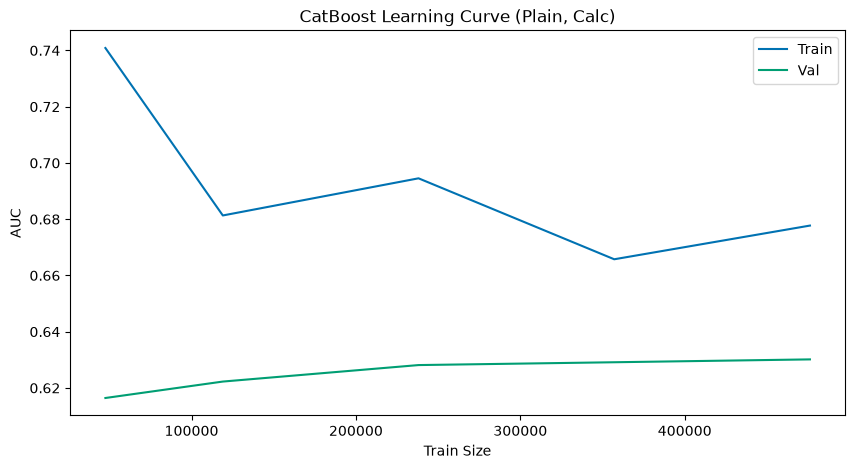

In [83]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("CatBoost Learning Curve (Plain, Calc)")

Text(0.5, 1.0, 'Trainingszeit per Datenmenge (Plain, Calc)')

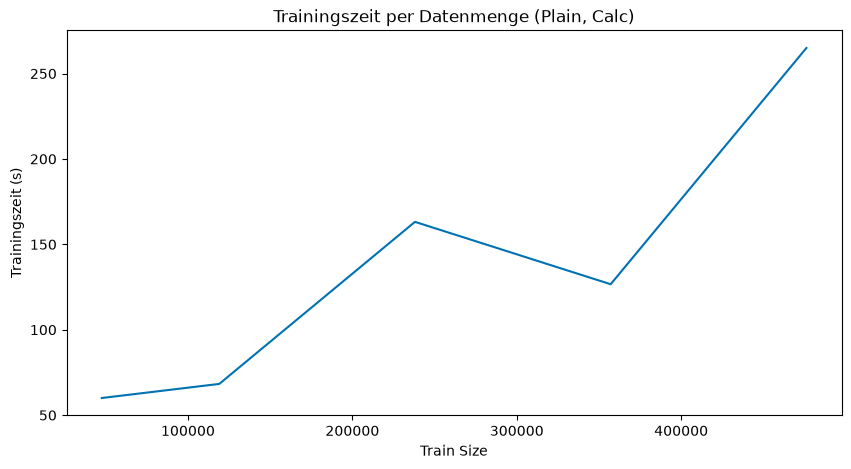

In [84]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["fit_time"])
ax.set_xlabel("Train Size")
ax.set_ylabel("Trainingszeit (s)")
ax.set_title("Trainingszeit per Datenmenge (Plain, Calc)")

## Ordered, fixed with calc

In [85]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train_cb) * trainset)
    idx_sub = rng.permutation(len(x_train_cb))[:n]
    x_sub, y_sub = x_train_cb.iloc[idx_sub], y_train.iloc[idx_sub]

    model = CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        eval_metric="AUC",
        thread_count=-1,
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        loss_function="Logloss",
        verbose=250,
        iterations=5000,
        boosting_type="Ordered"
        )

    start = time.time()
    model.fit(
        x_sub, y_sub,
        eval_set=[(x_val_cb, y_val)],
        verbose=False
        )
    fit_time = time.time() - start

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "best_iter": model.get_best_iteration(),
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val_cb)[:, 1]),
        "fit_time": fit_time
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

,train_size,anteil,best_iter,auc_train,auc_val,fit_time
0,47616,0.10,357,0.701423,0.615425,64.407797
1,119042,0.25,551,0.707119,0.624742,163.006279
2,238084,0.50,423,0.673474,0.623764,178.069145
3,357126,0.75,334,0.660404,0.625658,165.908498
4,476168,1.00,474,0.668067,0.628323,355.811151


Text(0.5, 1.0, 'CatBoost Learning Curve (Ordered, Calc)')

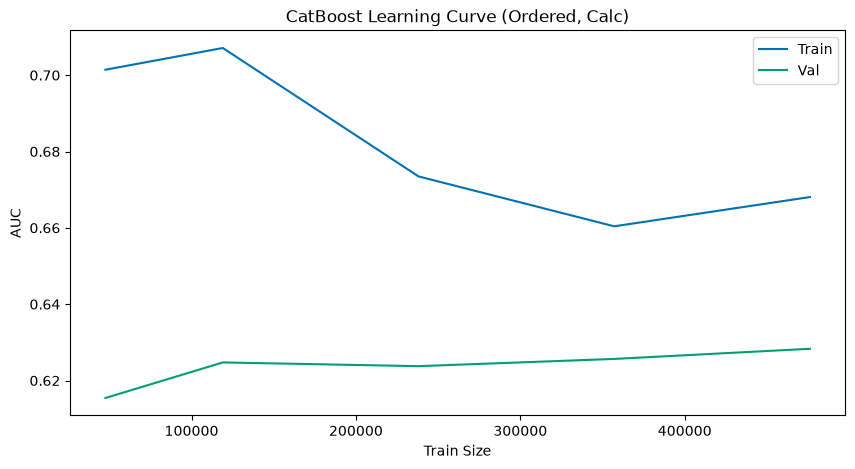

In [86]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("CatBoost Learning Curve (Ordered, Calc)")

Text(0.5, 1.0, 'Trainingszeit per Datenmenge (Ordered, Calc)')

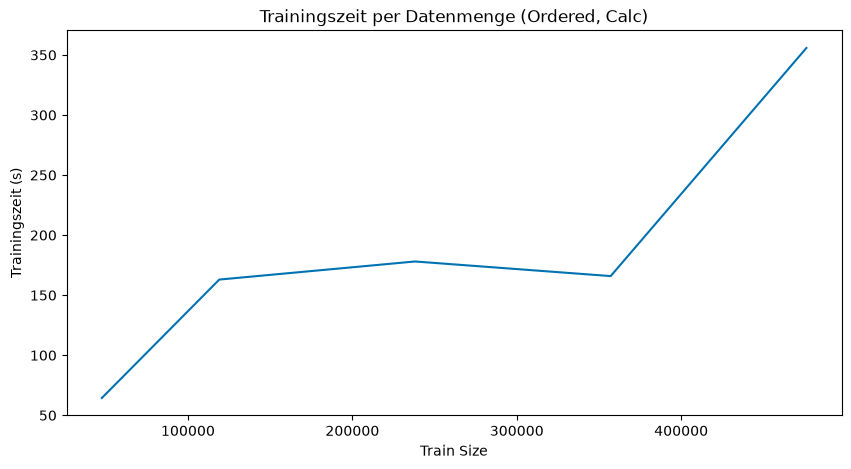

In [87]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["fit_time"])
ax.set_xlabel("Train Size")
ax.set_ylabel("Trainingszeit (s)")
ax.set_title("Trainingszeit per Datenmenge (Ordered, Calc)")

## Plain, fixed, without calc

In [88]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train_no_calc_cb) * trainset)
    idx_sub = rng.permutation(len(x_train_no_calc_cb))[:n]
    x_sub, y_sub = x_train_no_calc_cb.iloc[idx_sub], y_train.iloc[idx_sub]

    model = CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        eval_metric="AUC",
        thread_count=-1,
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        loss_function="Logloss",
        verbose=250,
        iterations=5000,
        boosting_type="Plain"
        )

    start = time.time()
    model.fit(
        x_sub, y_sub,
        eval_set=[(x_val_no_calc_cb, y_val)],
        verbose=False
        )
    fit_time = time.time() - start

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "best_iter": model.get_best_iteration(),
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val_no_calc_cb)[:, 1]),
        "fit_time": fit_time
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

,train_size,anteil,best_iter,auc_train,auc_val,fit_time
0,47616,0.10,325,0.695519,0.616447,45.324821
1,119042,0.25,322,0.671144,0.624002,60.043748
2,238084,0.50,659,0.675458,0.627985,143.675455
3,357126,0.75,452,0.663582,0.628434,135.376127
4,476168,1.00,387,0.659716,0.630820,155.942991


Text(0.5, 1.0, 'CatBoost Learning Curve (Plain, No Calc)')

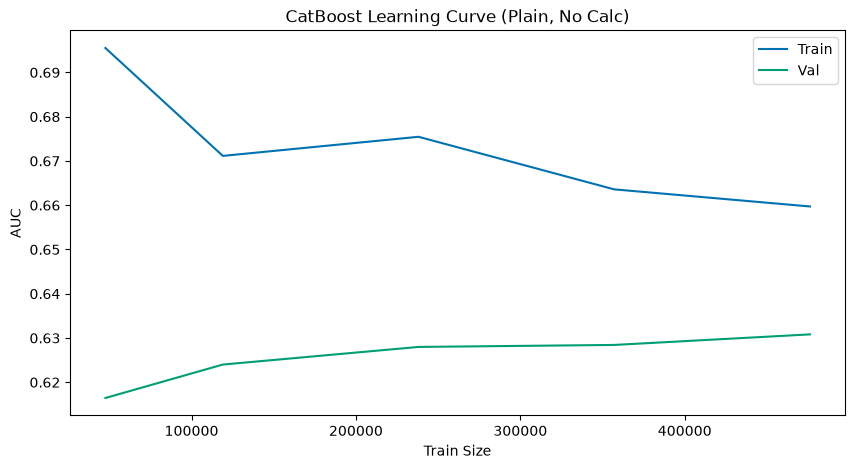

In [89]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("CatBoost Learning Curve (Plain, No Calc)")

Text(0.5, 1.0, 'Trainingszeit per Datenmenge (Plain, No Calc)')

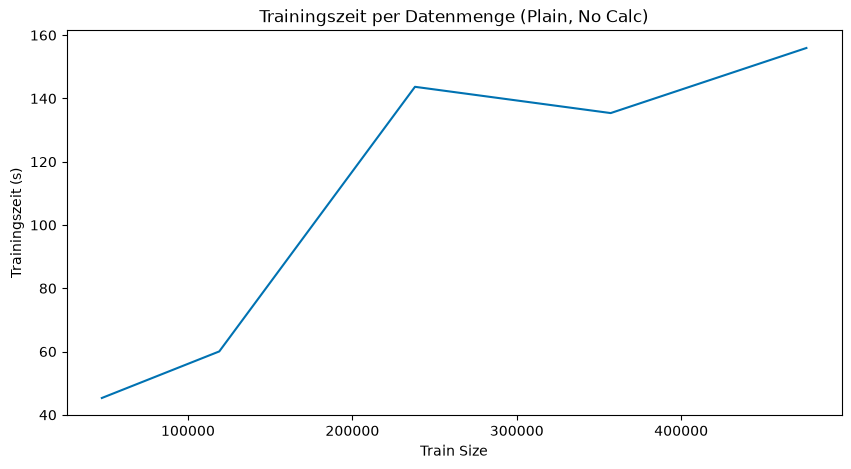

In [90]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["fit_time"])
ax.set_xlabel("Train Size")
ax.set_ylabel("Trainingszeit (s)")
ax.set_title("Trainingszeit per Datenmenge (Plain, No Calc)")

## Ordered, fixed, without calc

In [91]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train_no_calc_cb) * trainset)
    idx_sub = rng.permutation(len(x_train_no_calc_cb))[:n]
    x_sub, y_sub = x_train_no_calc_cb.iloc[idx_sub], y_train.iloc[idx_sub]

    model = CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        eval_metric="AUC",
        thread_count=-1,
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        loss_function="Logloss",
        verbose=250,
        iterations=5000,
        boosting_type="Ordered"
        )

    start = time.time()
    model.fit(
        x_sub, y_sub,
        eval_set=[(x_val_no_calc_cb, y_val)],
        verbose=False
        )
    fit_time = time.time() - start

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "best_iter": model.get_best_iteration(),
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val_no_calc_cb)[:, 1]),
        "fit_time": fit_time
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

,train_size,anteil,best_iter,auc_train,auc_val,fit_time
0,47616,0.10,369,0.684705,0.619216,60.399998
1,119042,0.25,408,0.673125,0.624942,120.452440
2,238084,0.50,627,0.671372,0.626553,240.971003
3,357126,0.75,636,0.672482,0.629918,270.356831
4,476168,1.00,1017,0.669763,0.632087,666.985405


Text(0.5, 1.0, 'CatBoost Learning Curve (Ordered, No Calc)')

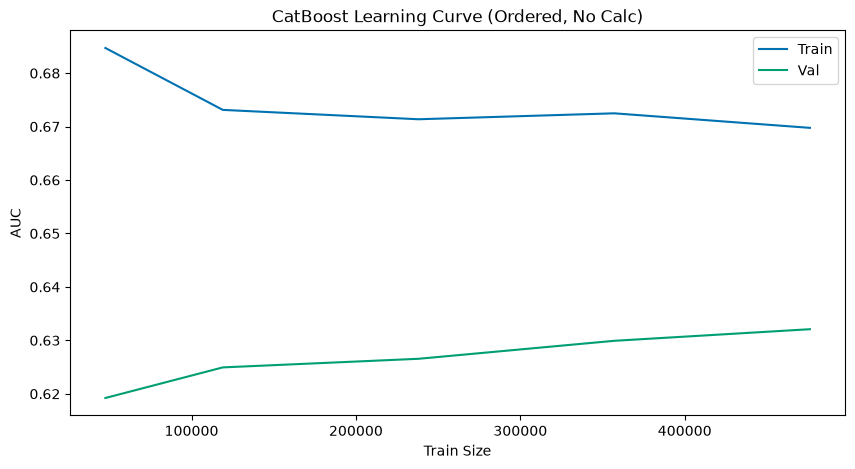

In [92]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("CatBoost Learning Curve (Ordered, No Calc)")

Text(0.5, 1.0, 'Trainingszeit per Datenmenge (Ordered, No Calc)')

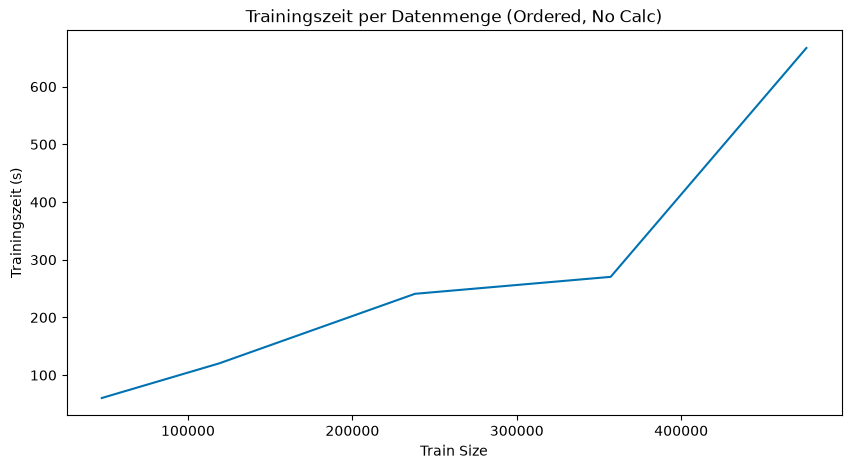

In [93]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["fit_time"])
ax.set_xlabel("Train Size")
ax.set_ylabel("Trainingszeit (s)")
ax.set_title("Trainingszeit per Datenmenge (Ordered, No Calc)")

## Notizen

- Ich habe gelesen, dass CatBoost selbst die Missing Values in numerischen Spalten verwenden kann, aber in kategorischen Spalten Fehler entstehen. Ich versuche es erstmal und schaue was passiert.
- L_cb_01 zeigt error wegen nan in cat features, ich schreibe eine hilfsfunktion um nan zu ersetzen
- col transformer muss df zurück geben wegen cat features von catboost
- Ich habe in 02 versucht wegen der AUfgabernstellung irgendwie eine pipeline zu benutzen, aber ich glaube momentan das macht für catboost wenig sinn. ich muss zum beispiel für das eval set sowieso händisch preprocessen.
- cat boost info wird bei jedem fit überschrieben, ich könnte es für jedes Modell anders speichern, aber ich denke in der experimentierphase wird dies das repo nur zu müllen. ich kümmere mich später via gitignore darum. bei der optimierung könnte ich das einsetzen um alle wichtigen daten zu speichern
- ich bin auf eine sehr alte meldung gestoßen, dass es wohl probleme mit dem panday category dtype gebe. ich überprüfe das mal indem ich dei cat features in objects umwandle
- Der Bug scheint hier keinerlei Einfluss zu nehmen also möglicherweise gefixt.
- kann leider nicht über gpu trainieren (kein cuda kein spaß)
- Plain ist wohl default, ordered führt zu extrem längerer prognostizierter train time.
- ordered scheint hier wenig bis keinen einfluss zu zeigen, aber höhere train times. Ich könnte wenn die Zeit es zulässt noch einmal einen optimierungsvergleichen machen.
- muss dran denken die cb und no calc variablen in df vorbereitung aufzunehmen
- calc drop bringt leichte verschlechterung in dem modell hier, aber die auf diff wird minimiert heißt mittel gegen overfitting potentiell
- catboost hat ein problem mit copy

Entscheidungen für die Hyperparameter Opti:
- Plain Boosting Type mit und ohne calc
- Wenn Zeit bleibt eventuell Ordered ohne calc laufen lassen, aber das wird wahrscheinlich extrem lange dauern
- Subsamplegrößen:
|Modell|Subsample|
|---|---|
|Plain mit Calc|75%|
|Plain ohne Calc|100% oder 75%|
|Ordered ohne Calc|75%|

Modelle:
|Modell IDX|Beschreibung|
|---|---|
|L_cb_01|Natives Modell ohne nan behandlung als Experiment (gescheitert)|
|L_cb_02|Natives Modell mit ersatz für nan in cat features, pipeline (gescheitert)|
|L_cb_03|Natives Modell, händisches Preprocessing, nan ersetzt in cat|
|L_cb_04|03 aber cat als object dtype|
|L_cb_05|early stop, early stopping rounds, logloss setze ich selber, thread_count aus -1 für effizienz, allow writing files auf false um nicht catboost info müll zu erzeugen. Also alle für mich erstmal fixen parameter und sonst default werte (wegen early stop setze ich iterations etwas höher als default 1000)|
|L_cb_06|boosting_type = plain|
|L_cb_07|boosting_type = ordered|
|L_cb_08|ps_calc_* drop|





Ressourcen [Aufrufdatun: 12.08.2026]:
- https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier
- https://catboost.ai/docs/en/references/training-parameters/common
- https://catboost.ai/docs/en/references/eval-metric__supported-metrics
- https://www.geeksforgeeks.org/machine-learning/catboost-parameters-and-hyperparameters/
- https://catboost.ai/docs/en/concepts/parameter-tuning
- https://mljourney.com/catboost-classifier-complete-guide/
- https://www.geeksforgeeks.org/machine-learning/catboost-cross-validation-and-hyperparameter-tuning/
- https://catboost.ai/docs/en/concepts/algorithm-missing-values-processing
- https://www.geeksforgeeks.org/machine-learning/handling-missing-values-with-catboost/
- https://stackoverflow.com/questions/70849918/missing-values-in-categorical-variables-in-catboost-python
- https://catboost.ai/docs/en/references/training-parameters/output
- https://catboost.ai/docs/en/concepts/python-reference_catboost_fit
- https://github.com/catboost/catboost/issues/814
- https://github.com/catboost/catboost/issues/757